In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Selecting Dataset**

In [ ]:
import os
import zipfile

# Path to dataset folder
dataset_dir = "/content/drive/MyDrive/Deepfake_Datasets"

# List all .zip files in the folder
zip_files = [f for f in os.listdir(dataset_dir) if f.endswith('.zip')]

# Display choices
print("Available datasets:")
for i, f in enumerate(zip_files):
    print(f"{i+1}. {f}")


# Let user select a dataset
choice = int(input("Enter the number of the dataset to extract: ")) - 1
selected_dataset = zip_files[choice]

# Extract the selected dataset
zip_path = os.path.join(dataset_dir, selected_dataset)
extract_path = "/content/extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset '{selected_dataset}' extracted successfully to {extract_path}")

Available datasets:
1. SDFVD.zip
2. UADFV.zip
3. DFD_original sequences.zip
Enter the number of the dataset to extract: 2
Dataset 'UADFV.zip' extracted successfully to /content/extracted


Extract Frame From videos

In [ ]:
# extract Frames from videos
import cv2
import os

def extract_frames_from_videos(source_dir, target_dir, max_frames=10, frame_interval=5):
    os.makedirs(target_dir, exist_ok=True)
    video_files = [f for f in os.listdir(source_dir) if f.endswith('.mp4')]

    for video_file in video_files:
        video_path = os.path.join(source_dir, video_file)
        output_folder = os.path.join(target_dir, os.path.splitext(video_file)[0])
        os.makedirs(output_folder, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        frame_count = 0
        saved_count = 0

        while cap.isOpened() and saved_count < max_frames:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_count % frame_interval == 0:
                frame_path = os.path.join(output_folder, f"frame_{saved_count:03d}.jpg")
                cv2.imwrite(frame_path, frame)
                saved_count += 1
            frame_count += 1
        cap.release()

# directories ***
real_video_dir = "/content/extracted/UADFV/real"
fake_video_dir = "/content/extracted/UADFV/fake"
real_output_dir = "/content/data/Real"
fake_output_dir = "/content/data/Fake"
# configs
max_frames = 15
frame_interval = 3

# Extract frames
extract_frames_from_videos(real_video_dir, real_output_dir, max_frames, frame_interval)
extract_frames_from_videos(fake_video_dir, fake_output_dir, max_frames, frame_interval)


**Preprocessing** - Prepare the Dataset

**Test set Making**

In [ ]:
import os
import zipfile
import cv2

# --- Configuration for Test Dataset ---
TEST_ZIP = "SDFVD.zip"  # <-- hardcoded test dataset
ZIP_PATH = "/content/drive/MyDrive/Deepfake_Datasets/" + TEST_ZIP
EXTRACT_PATH = "/content/"  # or dynamically extract from zip name
TEST_DATA_PATH = "/content/test_data"
MAX_FRAMES = 10
FRAME_INTERVAL = 5

# --- Step 1: Extract ZIP File ---
def extract_test_zip(zip_path, extract_to):
    print(f"Extracting {zip_path}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print("Extraction complete.")

# --- Step 2: Extract Frames from Video Files ---
def extract_test_frames(source_dir, target_dir, label, max_frames=10, interval=5):
    input_dir = os.path.join(source_dir, label)
    output_dir = os.path.join(target_dir, label)
    os.makedirs(output_dir, exist_ok=True)

    video_files = [f for f in os.listdir(input_dir) if f.endswith('.mp4')]
    for video in video_files:
        video_path = os.path.join(input_dir, video)
        save_dir = os.path.join(output_dir, os.path.splitext(video)[0])
        os.makedirs(save_dir, exist_ok=True)

        cap = cv2.VideoCapture(video_path)
        frame_count = 0
        saved_count = 0

        while cap.isOpened() and saved_count < max_frames:
            ret, frame = cap.read()
            if not ret:
                break
            if frame_count % interval == 0:
                frame_path = os.path.join(save_dir, f"frame_{saved_count:03d}.jpg")
                cv2.imwrite(frame_path, frame)
                saved_count += 1
            frame_count += 1
        cap.release()

# --- Run the Setup ---
extract_test_zip(ZIP_PATH, EXTRACT_PATH)

# rename folder names to match expected structure for dataset with different name
EXTRACT_PATH = os.path.join(EXTRACT_PATH, TEST_ZIP.replace(".zip", ""))

real_path = os.path.join(EXTRACT_PATH, "videos_real")
fake_path = os.path.join(EXTRACT_PATH, "videos_fake")
if os.path.exists(real_path):
    os.rename(real_path, os.path.join(EXTRACT_PATH, "Real"))
    print("Renamed 'videos_real' to 'Real'")
else:
    print("'videos_real' not found")
if os.path.exists(fake_path):
    os.rename(fake_path, os.path.join(EXTRACT_PATH, "Fake"))
    print("Renamed 'videos_fake' to 'Fake'")
else:
    print("'videos_fake' not found")

#EXTRACTED_FOLDER = os.path.join(EXTRACT_PATH, TEST_ZIP.replace(".zip", ""))
EXTRACTED_FOLDER = EXTRACT_PATH

extract_test_frames(EXTRACTED_FOLDER, TEST_DATA_PATH, "Real", max_frames=MAX_FRAMES, interval=FRAME_INTERVAL)
extract_test_frames(EXTRACTED_FOLDER, TEST_DATA_PATH, "Fake", max_frames=MAX_FRAMES, interval=FRAME_INTERVAL)

print("Test dataset preparation complete.")


Extracting /content/drive/MyDrive/Deepfake_Datasets/SDFVD.zip...
Extraction complete.
Renamed 'videos_real' to 'Real'
Renamed 'videos_fake' to 'Fake'
Test dataset preparation complete.


In [ ]:
# preparing Dataset
# augmentation & testset
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras import layers

# --- Configuration ---
IMAGE_SIZE = (299, 299)
BATCH_SIZE = 32
DATA_DIR = "/content/data"           # contains 'Real' and 'Fake' subfolders
TEST_DIR = "/content/test_data"      # optional - should also have 'Real' and 'Fake'
ENABLE_AUGMENTATION = True
INCLUDE_TEST_SET = True


# --- Data Augmentation Layer ---
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# --- Load Datasets Function ---
def load_datasets(data_dir=DATA_DIR, test_dir=TEST_DIR, augment=ENABLE_AUGMENTATION, include_test=INCLUDE_TEST_SET):
    print("Loading training and validation datasets...")

    train_ds = image_dataset_from_directory(
        data_dir,
        labels="inferred",
        label_mode="int",
        validation_split=0.2,
        subset="training",
        seed=123,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE
    )

    val_ds = image_dataset_from_directory(
        data_dir,
        labels="inferred",
        label_mode="int",
        validation_split=0.2,
        subset="validation",
        seed=123,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE
    )

    # Apply augmentation to training dataset if enabled
    if augment:
        print("Applying data augmentation to training data")
        train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

    # Prefetch for performance
    train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

    if include_test and os.path.exists(test_dir):
        print(" Loading test dataset...")
        test_ds = image_dataset_from_directory(
            test_dir,
            labels="inferred",
            label_mode="int",
            image_size=IMAGE_SIZE,
            batch_size=BATCH_SIZE
        ).prefetch(buffer_size=tf.data.AUTOTUNE)
    else:
        test_ds = None
        if include_test:
            print(" Test directory not found. Skipping test dataset.")

    return train_ds, val_ds, test_ds if include_test else None

train_dataset, val_dataset, test_dataset = load_datasets()


Loading training and validation datasets...
Found 1470 files belonging to 2 classes.
Using 1176 files for training.
Found 1470 files belonging to 2 classes.
Using 294 files for validation.
Applying data augmentation to training data
 Test directory not found. Skipping test dataset.


1. Model Building Module   *initial*

In [ ]:
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models

def build_model():
    base_model = Xception(include_top=False, weights='imagenet', input_shape=(299, 299, 3))
    base_model.trainable = False  # Freeze base

    inputs = layers.Input(shape=(299, 299, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model


FINE TUNe   -This was done after initila binary classifiction training...

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam

# Load full model
model = load_model('/content/best_model.keras')

# Unfreeze last N layers
for layer in model.layers[-30:]:
    layer.trainable = True

# Recompile
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

callbacks = get_callbacks()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=callbacks
)


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5456 - loss: 0.6722
Epoch 1: val_loss improved from inf to 0.33931, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 170s 3s/step - accuracy: 0.5495 - loss: 0.6706 - val_accuracy: 0.9150 - val_loss: 0.3393 - learning_rate: 1.0000e-04
Epoch 2/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9480 - loss: 0.2603
Epoch 2: val_loss did not improve from 0.33931
37/37 ━━━━━━━━━━━━━━━━━━━━ 119s 2s/step - accuracy: 0.9485 - loss: 0.2583 - val_accuracy: 0.6701 - val_loss: 1.9874 - learning_rate: 1.0000e-04
Epoch 3/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9691 - loss: 0.1070
Epoch 3: val_loss improved from 0.33931 to 0.26021, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9691 - loss: 0.1067 - val_accuracy: 0.9354 - val_loss: 0.2602 - learning_rate: 1.0000e-04
Epoch 4/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9834 - loss: 0.0621
Epoch 4: val_loss improv

In [ ]:
model.save("xception_deepfake_model_FineTuned(90+).keras")


2. Define Callbacks Module

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
import datetime

def get_callbacks():
    log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    return [
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            filepath="best_model.keras",
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=1
        ),
        TensorBoard(
            log_dir=log_dir,
            histogram_freq=1
        )
    ]


3. Compile and Train the Model

In [ ]:
model = build_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = get_callbacks()

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=8,
    callbacks=callbacks
)


Epoch 1/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4776 - loss: 8.5705   
Epoch 1: val_loss improved from inf to 1.25371, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 66s 2s/step - accuracy: 0.4780 - loss: 8.4858 - val_accuracy: 0.5000 - val_loss: 1.2537 - learning_rate: 0.0010
Epoch 2/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 793ms/step - accuracy: 0.4982 - loss: 1.3658
Epoch 2: val_loss improved from 1.25371 to 0.79264, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.4980 - loss: 1.3584 - val_accuracy: 0.4898 - val_loss: 0.7926 - learning_rate: 0.0010
Epoch 3/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.4707 - loss: 0.7183
Epoch 3: val_loss improved from 0.79264 to 0.76815, saving model to best_model.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.4711 - loss: 0.7180 - val_accuracy: 0.5136 - val_loss: 0.7682 - learning_rate: 0.0010
Epoch 4/8
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 779ms/step - accuracy: 0.5308 - loss:

**1. Evaluate Model Performance**

In [ ]:
loss, accuracy = model.evaluate(val_dataset)
print(f"Validation Accuracy: {accuracy:.2f}")


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 200ms/step - accuracy: 0.5339 - loss: 0.7230
Validation Accuracy: 0.50


**2. Test the Model on New Images**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_and_show(img_path, model):
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img) / 255.0
    img_batch = np.expand_dims(img_array, axis=0)
    prediction = model.predict(img_batch)[0][0]

    label = "Real" if prediction >= 0.5 else "Fake"
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    plt.imshow(img_array)
    plt.title(f"{label} (Confidence: {confidence:.2f})", color='green' if label == "Real" else 'red')
    plt.axis('off')
    plt.show()


**3. Save the Final Model**

In [ ]:
model.save("xception_deepfake_model_initial.keras")


Visualize Training Progress

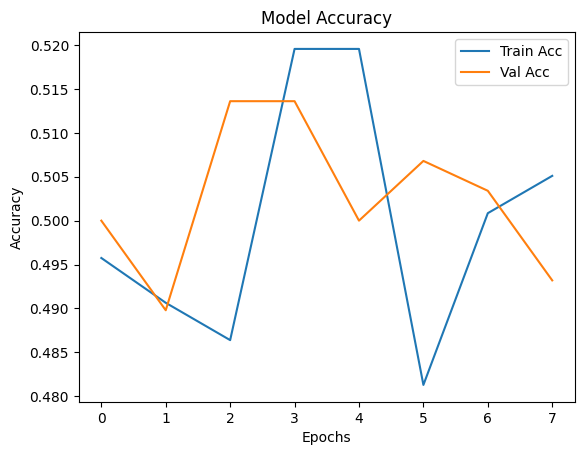

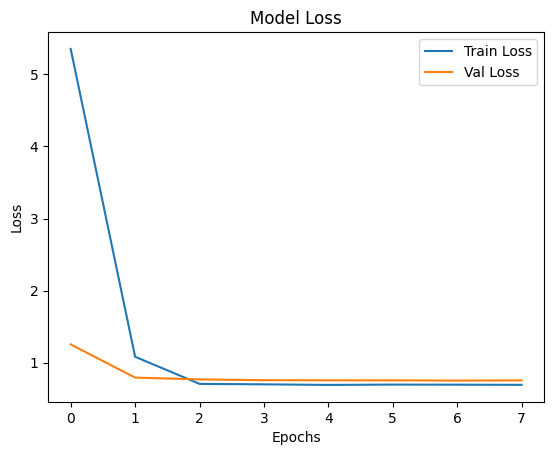

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Model Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_training_history(history)


**Test Set Evaluation**

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import random

# Load trained model
model = load_model('/content/best_model.keras')

# Define test directory and class names
test_dir = '/content/test_data/'  # Adjust path if needed
categories = ['Real', 'Fake']

# Helper: Preprocess an image
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array / 255.0

# Helper: Predict and show the result
def predict_and_display(img_path):
    img_array = preprocess_image(img_path)
    pred = model.predict(img_array)[0][0]
    label = "Fake" if pred > 0.5 else "Real"
    confidence = pred if pred > 0.5 else 1 - pred

    # Display image
    img = image.load_img(img_path, target_size=(299, 299))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {label} ({confidence*100:.2f}%)")
    plt.show()

# Recursively collect all .jpg images from Real and Fake folders
all_images = []
for cat in categories:
    cat_path = os.path.join(test_dir, cat)
    for root, dirs, files in os.walk(cat_path):
        for file in files:
            if file.lower().endswith('.jpg'):
                all_images.append(os.path.join(root, file))

# Shuffle and test a few
random.shuffle(all_images)
num_samples = 8  # Change if you want more/less
for img_path in all_images[:num_samples]:
    print(f"Testing image: {img_path}")
    predict_and_display(img_path)


ReDONE Test

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import random

# Load trained model
model = load_model('/content/best_model.keras')

# Define test directory
test_dir = '/content/test_data/'
categories = ['Real', 'Fake']  # Ensure these match folder names exactly

# Helper: Preprocess an image
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array / 255.0

# Helper: Predict and show the result
def predict_and_display(img_path, true_label):
    try:
        img_array = preprocess_image(img_path)
        pred = model.predict(img_array)[0][0]
        predicted_label = 1 if pred > 0.5 else 0
        label = categories[predicted_label]
        confidence = pred if predicted_label == 1 else 1 - pred

        # Display image
        img = image.load_img(img_path, target_size=(299, 299))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted: {label} ({confidence*100:.2f}%) | True: {categories[true_label]}")
        plt.show()

        return predicted_label
    except Exception as e:
        print(f"Skipping {img_path}: {e}")
        return None

# Recursively collect all .jpg images from Real and Fake folders
all_images = []
image_labels = []

for cat in categories:
    cat_path = os.path.join(test_dir, cat)
    label = 0 if cat == 'Real' else 1
    for root, dirs, files in os.walk(cat_path):
        for file in files:
            if file.lower().endswith('.jpg'):
                all_images.append(os.path.join(root, file))
                image_labels.append(label)

# Shuffle and test a sample
combined = list(zip(all_images, image_labels))
random.shuffle(combined)

# Test sample size (change as needed or use all)
num_samples = 8
sampled = combined[:num_samples]

y_true = []
y_pred = []

for img_path, true_label in sampled:
    print(f"Testing image: {img_path}")
    prediction = predict_and_display(img_path, true_label)
    if prediction is not None:
        y_true.append(true_label)
        y_pred.append(prediction)

# Evaluation
if y_true and y_pred:
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=categories))
else:
    print("No valid predictions to evaluate.")


No valid predictions to evaluate.


test on valid set

Testing image: /content/data/Real/0021/frame_010.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


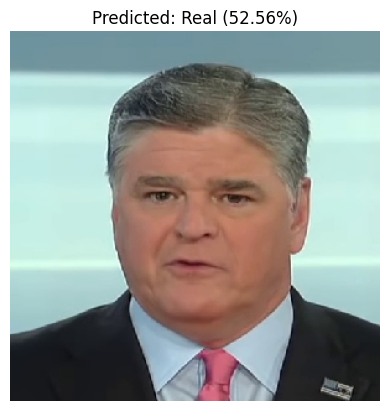

Testing image: /content/data/Real/0002/frame_003.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


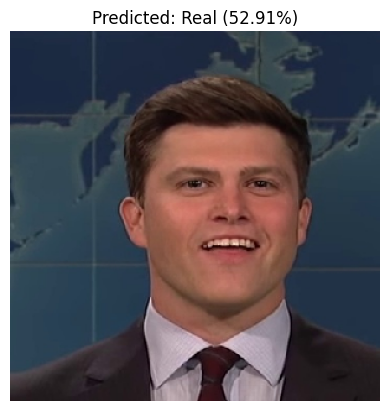

Testing image: /content/data/Fake/0018_fake/frame_011.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


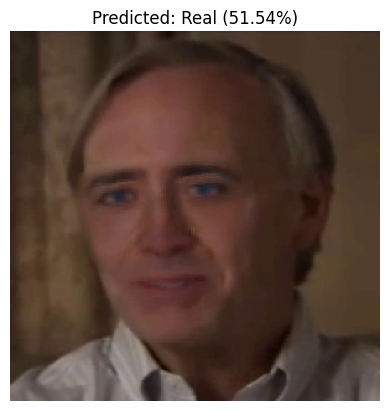

Testing image: /content/data/Real/0038/frame_011.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


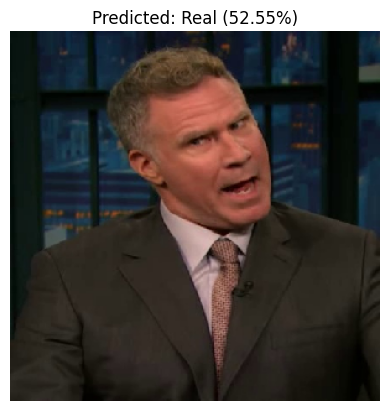

Testing image: /content/data/Fake/0037_fake/frame_001.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


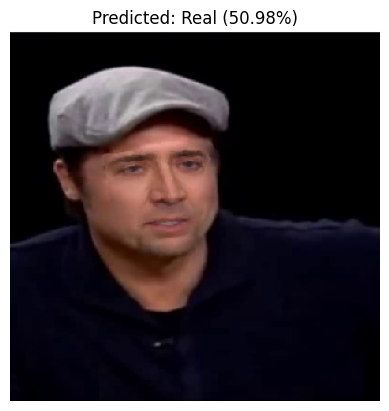

Testing image: /content/data/Real/0032/frame_010.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


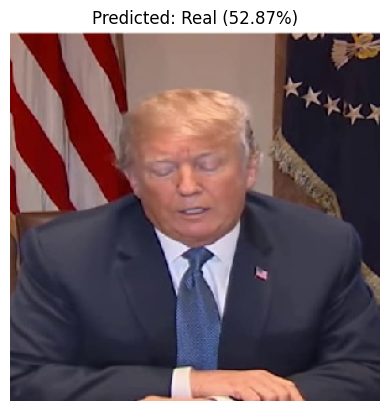

Testing image: /content/data/Real/0012/frame_005.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


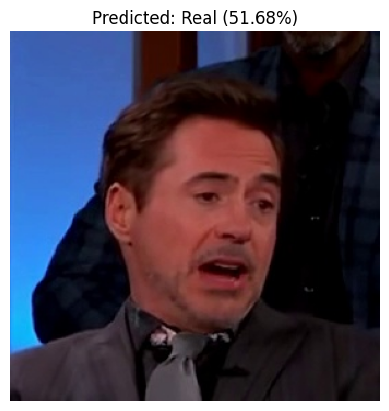

Testing image: /content/data/Fake/0009_fake/frame_014.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


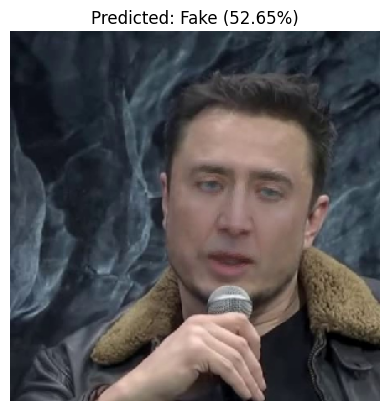

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import random

# Load trained model
model = load_model('/content/best_model.keras')

# Set validation data directory
val_dir = '/content/data/'  # adjust path if needed
categories = ['Real', 'Fake']

# Helper: Preprocess image
def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(299, 299))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array / 255.0

# Helper: Predict and show image
def predict_and_display(img_path):
    img_array = preprocess_image(img_path)
    pred = model.predict(img_array)[0][0]
    label = "Fake" if pred > 0.5 else "Real"
    confidence = pred if pred > 0.5 else 1 - pred

    img = image.load_img(img_path, target_size=(299, 299))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Predicted: {label} ({confidence*100:.2f}%)")
    plt.show()

# Collect images
all_images = []
for cat in categories:
    cat_path = os.path.join(val_dir, cat)
    for root, _, files in os.walk(cat_path):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                all_images.append(os.path.join(root, file))

# Shuffle and test some
random.shuffle(all_images)
for img_path in all_images[:8]:
    print(f"Testing image: {img_path}")
    predict_and_display(img_path)
